# 🔍 Fraud Detection in Unstructured Financial Logs

---

**Approach:** unsupervised anomaly detection pipeline

| Layer | Component | Purpose |
|---|---|---|
| 1 | Multi-format log parser | Extract structured fields from 8+ log formats |
| 2 | Point-in-time feature engineering | Build behavioral features with no future leakage |
| 3 | Rule Engine | Deterministic, user-context-aware fraud flags |
| 4 | Isolation Forest | Global anomaly detection in continuous feature space |
| 5 | Deep Autoencoder + Entity Embeddings | Pattern anomalies across continuous + categorical features |
| 6 | Weighted Ensemble | Composite risk score → Risk tiers |
| 7 | Explainability | SHAP + reconstruction error + per-transaction reports |

**Key design decisions:**
- All behavioral aggregates are *point-in-time correct* (no future data leakage)  
- Isolation Forest and Autoencoder are *independently trained* (genuine ensemble)
- Categorical variables handled differently per model: rarity encodings for IF, entity embeddings for AE
- Cold-start users handled via global population priors with explicit flag


In [1]:
import os
import sys
import warnings
import json
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
print(f"✅ PyTorch {torch.__version__} available | Device: "
     f"{'cuda' if torch.cuda.is_available() else 'cpu'}")
TORCH_AVAILABLE = True



from src.parser.log_parser       import parse_dataframe
# from src.features.feature_engineer import (
#     engineer_features, compute_global_priors,
#     compute_rarity_encodings, CONTINUOUS_FEATURES, CATEGORICAL_COLS
# )
# from src.models.rule_engine       import apply_rules
# from src.models.isolation_forest  import IsolationForestDetector
# from src.models.autoencoder       import AutoencoderDetector
# from src.models.ensemble          import compute_ensemble_score, get_top_anomalies
# from src.evaluation.evaluator     import (
#     synthetic_injection_test, precision_at_k,
#     cross_model_agreement, plot_score_distributions, run_full_evaluation
# )
# from src.explainability.explainer import generate_batch_reports

print("\\n all modules loaded successfully.")


✅ PyTorch 2.10.0 available | Device: cpu
\n all modules loaded successfully.


In [2]:
# Generate dataset if it doesn't exist
RAW_DATA_PATH = "../data/MP Fraud Takehome Task 2026 - Sheet1.csv"

if not os.path.exists(RAW_DATA_PATH):
    print("Provide correct path to raw data")
else:
    print(f"Dataset present at {RAW_DATA_PATH}")

# Load raw logs
raw_df = pd.read_csv(RAW_DATA_PATH)

print(f"Raw dataset shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")
print(f"Sample raw logs:")
raw_df["raw_log"].head(10).to_frame()


Dataset present at ../data/MP Fraud Takehome Task 2026 - Sheet1.csv
Raw dataset shape: (8876, 1)
Columns: ['raw_log']
Sample raw logs:


,raw_log
0,2025-07-05 19:18:10::user1069::withdrawal::299...
1,MALFORMED_LOG
2,usr:user1076|cashout|€4821.85|Glasgow|2025-07-...
3,2025-07-20 05:38:14 >> [user1034] did top-up -...
4,2025-06-13 10:04:51 >> [user1068] did deposit ...
5,2025-07-29 23:47:37 | user: user1014 | txn: de...
6,MALFORMED_LOG
7,2025-06-23 14:45:58 - user=user1075 - action=d...
8,2025-07-31 06:50:50 | user: user1071 | txn: ca...
9,2025-07-07 20:42:12 - user=user1098 - action=d...


## 2. Log Parsing

The parser uses a 4-layer cascade:
1. **Regex cascade** — 8 compiled patterns covering all known formats
2. **Heuristic fallback** — field-by-field micro-pattern extraction  
3. **spaCy EntityRuler** — rule-based NLP matcher (not statistical NER)
4. **LLM fallback** — optional API call (only if `ANTHROPIC_API_KEY` is set)


In [3]:
# Parse all raw logs through the multi-layer parser
parsed_df = parse_dataframe(raw_df, log_col="raw_log")

print(f"Parsed DataFrame shape: {parsed_df.shape}")
parsed_df[["user_id","timestamp","txn_type","amount","currency",
           "city","device","parse_method","parse_success"]].head(10)



  PARSE QUALITY REPORT
  Total rows    : 8876
  Parsed OK     : 7774 (87.6%)
  Failed        : 1102 (12.4%)

  Breakdown by method:
    F5                    1138  (12.8%)
    F7                    1132  (12.8%)
    F6                    1121  (12.6%)
    F2                    1119  (12.6%)
    F1                    1109  (12.5%)
    MALFORMED             1102  (12.4%)
    F4                    1089  (12.3%)
    F3                    1066  (12.0%)

Parsed DataFrame shape: (8876, 10)


,user_id,timestamp,txn_type,amount,currency,city,device,parse_method,parse_success
0,user1069,2025-07-05 19:18:10,withdrawal,2995.12,UNKNOWN,London,iPhone 13,F1,True
1,UNKNOWN,NaT,UNKNOWN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,MALFORMED,False
2,user1076,2025-07-15 12:56:05,withdrawal,4821.85,€,Glasgow,Pixel 6,F2,True
3,user1034,2025-07-20 05:38:14,deposit,2191.06,€,UNKNOWN,iPhone 13,F3,True
4,user1068,2025-06-13 10:04:51,deposit,1691.09,€,Glasgow,UNKNOWN,F3,True
5,user1014,2025-07-29 23:47:37,deposit,3539.50,£,Glasgow,iPhone 13,F5,True
6,UNKNOWN,NaT,UNKNOWN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,MALFORMED,False
7,user1075,2025-06-23 14:45:58,withdrawal,1215.74,$,Leeds,Samsung Galaxy S10,F4,True
8,user1071,2025-07-31 06:50:50,withdrawal,1772.13,$,UNKNOWN,Nokia 3310,F5,True
9,user1098,2025-07-07 20:42:12,deposit,304.00,€,Birmingham,Nokia 3310,F4,True


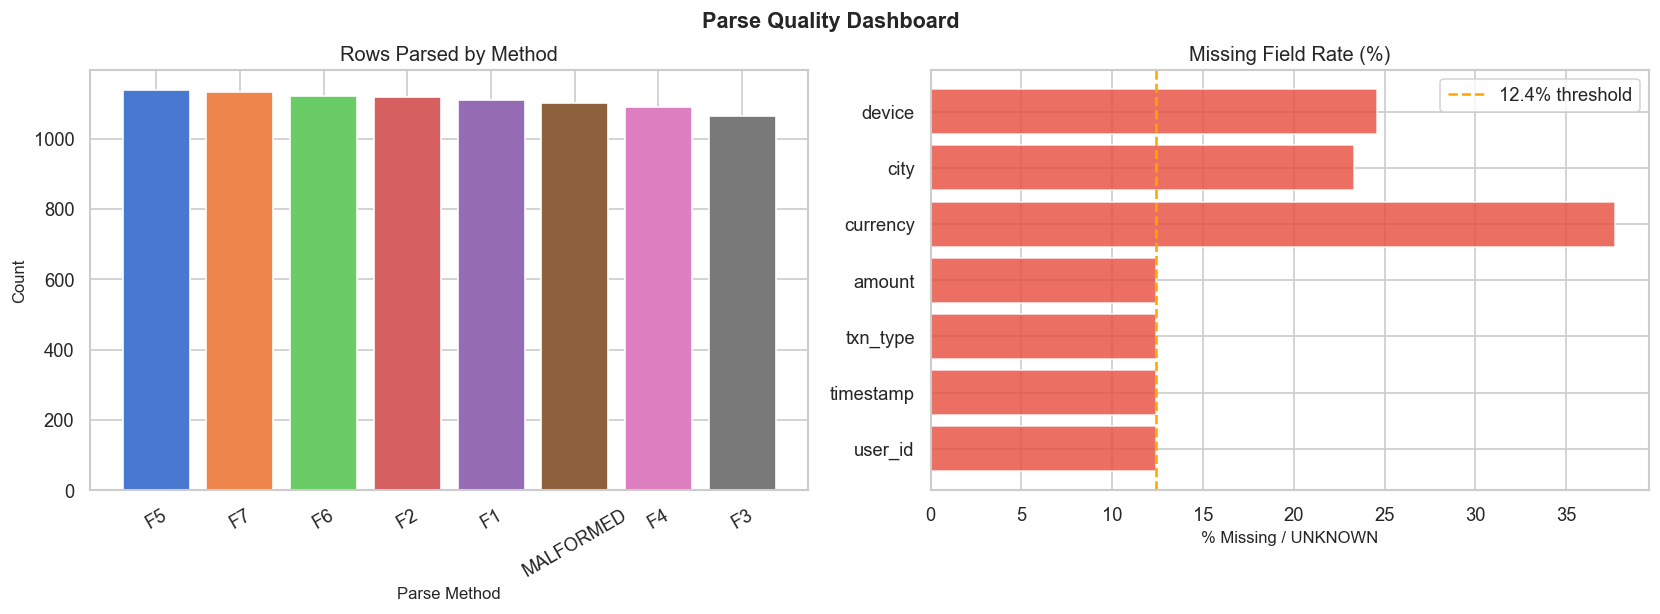

In [4]:
# ── Parse Quality Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parse method distribution
method_counts = parsed_df["parse_method"].value_counts()
axes[0].bar(method_counts.index, method_counts.values,
            color=sns.color_palette("muted", len(method_counts)))
axes[0].set_title("Rows Parsed by Method")
axes[0].set_xlabel("Parse Method")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Missing fields heatmap
missing_cols = ["user_id","timestamp","txn_type","amount","currency","city","device"]
def is_missing(series):
    """Catch UNKNOWN strings, None, NaN, NaT, and empty strings."""
    return (
        series.isin(["UNKNOWN", "None", ""])  # string sentinels
        | series.isna()                        # catches NaN, NaT, None, pd.NA
    )
missing_pct  = parsed_df[missing_cols].apply(is_missing).mean() * 100
axes[1].barh(missing_pct.index, missing_pct.values, color="#e74c3c", alpha=0.8)
axes[1].set_title("Missing Field Rate (%)")
axes[1].set_xlabel("% Missing / UNKNOWN")
axes[1].axvline(12.4, color="orange", linestyle="--", label="12.4% threshold")
axes[1].legend()

plt.tight_layout()
plt.suptitle("Parse Quality Dashboard", fontsize=13, y=1.02, fontweight="bold")

plt.show()


In [5]:
parsed_df.shape

(8876, 10)

In [6]:
raw_df.shape

(8876, 1)

In [7]:
raw_df[raw_df['raw_log']=='MALFORMED_LOG'].shape

(1102, 1)

In [8]:
parsed_df[parsed_df['raw_log']=='MALFORMED_LOG'].shape

(1102, 10)

In [9]:
valid_logs = parsed_df[parsed_df['raw_log']!='MALFORMED_LOG']

In [10]:
valid_logs.shape

(7774, 10)

In [11]:
valid_logs.loc[8875]['raw_log']

'2025-07-27 17:57:22::user1048::refund::2988.49::Leeds::Xiaomi Mi 11'

In [12]:
parsed_df['parse_success'].value_counts()

parse_success
True     7774
False    1102
Name: count, dtype: int64

In [13]:
valid_logs.tail()

,raw_log,user_id,timestamp,txn_type,amount,currency,city,device,parse_method,parse_success
8871,usr:user1058|debit|£3992.06|Leeds|2025-06-10 0...,user1058,2025-06-10 03:55:41,withdrawal,3992.06,£,Leeds,Pixel 6,F2,True
8872,08/07/2025 08:50:09 ::: user1069 *** WITHDRAWA...,user1069,2025-07-08 08:50:09,withdrawal,8.00,UNKNOWN,Birmingham,Nokia,HEURISTIC,True
8873,2025-07-31 07:41:34::user1024::deposit::1331.2...,user1024,2025-07-31 07:41:34,deposit,1331.20,UNKNOWN,Cardiff,Nokia 3310,F1,True
8874,2025-06-23 05:14:03 >> [user1029] did withdraw...,user1029,2025-06-23 05:14:03,withdrawal,4203.63,£,London,Xiaomi Mi 11,F3,True
8875,2025-07-27 17:57:22::user1048::refund::2988.49...,user1048,2025-07-27 17:57:22,refund,2988.49,UNKNOWN,Leeds,Xiaomi Mi 11,F1,True


In [30]:
# Filter to successfully parsed rows for EDA
clean_df = parsed_df[parsed_df["parse_success"] == True].copy()
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"])
clean_df["amount"]    = pd.to_numeric(clean_df["amount"], errors="coerce")

print(f"Clean rows for EDA: {len(clean_df)}")
print(f"Unique users       : {clean_df['user_id'].nunique()}")
print(f"Date range         : {clean_df['timestamp'].min()} → {clean_df['timestamp'].max()}")
print(f"Amount range       : {clean_df['amount'].min():.2f} → {clean_df['amount'].max():.2f}")
print(f"\\nTransaction types:")
print(clean_df["txn_type"].value_counts())


Clean rows for EDA: 7774
Unique users       : 86
Date range         : 2025-06-01 11:41:41 → 2025-07-31 11:14:57
Amount range       : 1.62 → 4998.25
\nTransaction types:
txn_type
withdrawal    2993
deposit       1978
transfer       958
purchase       940
refund         905
Name: count, dtype: int64


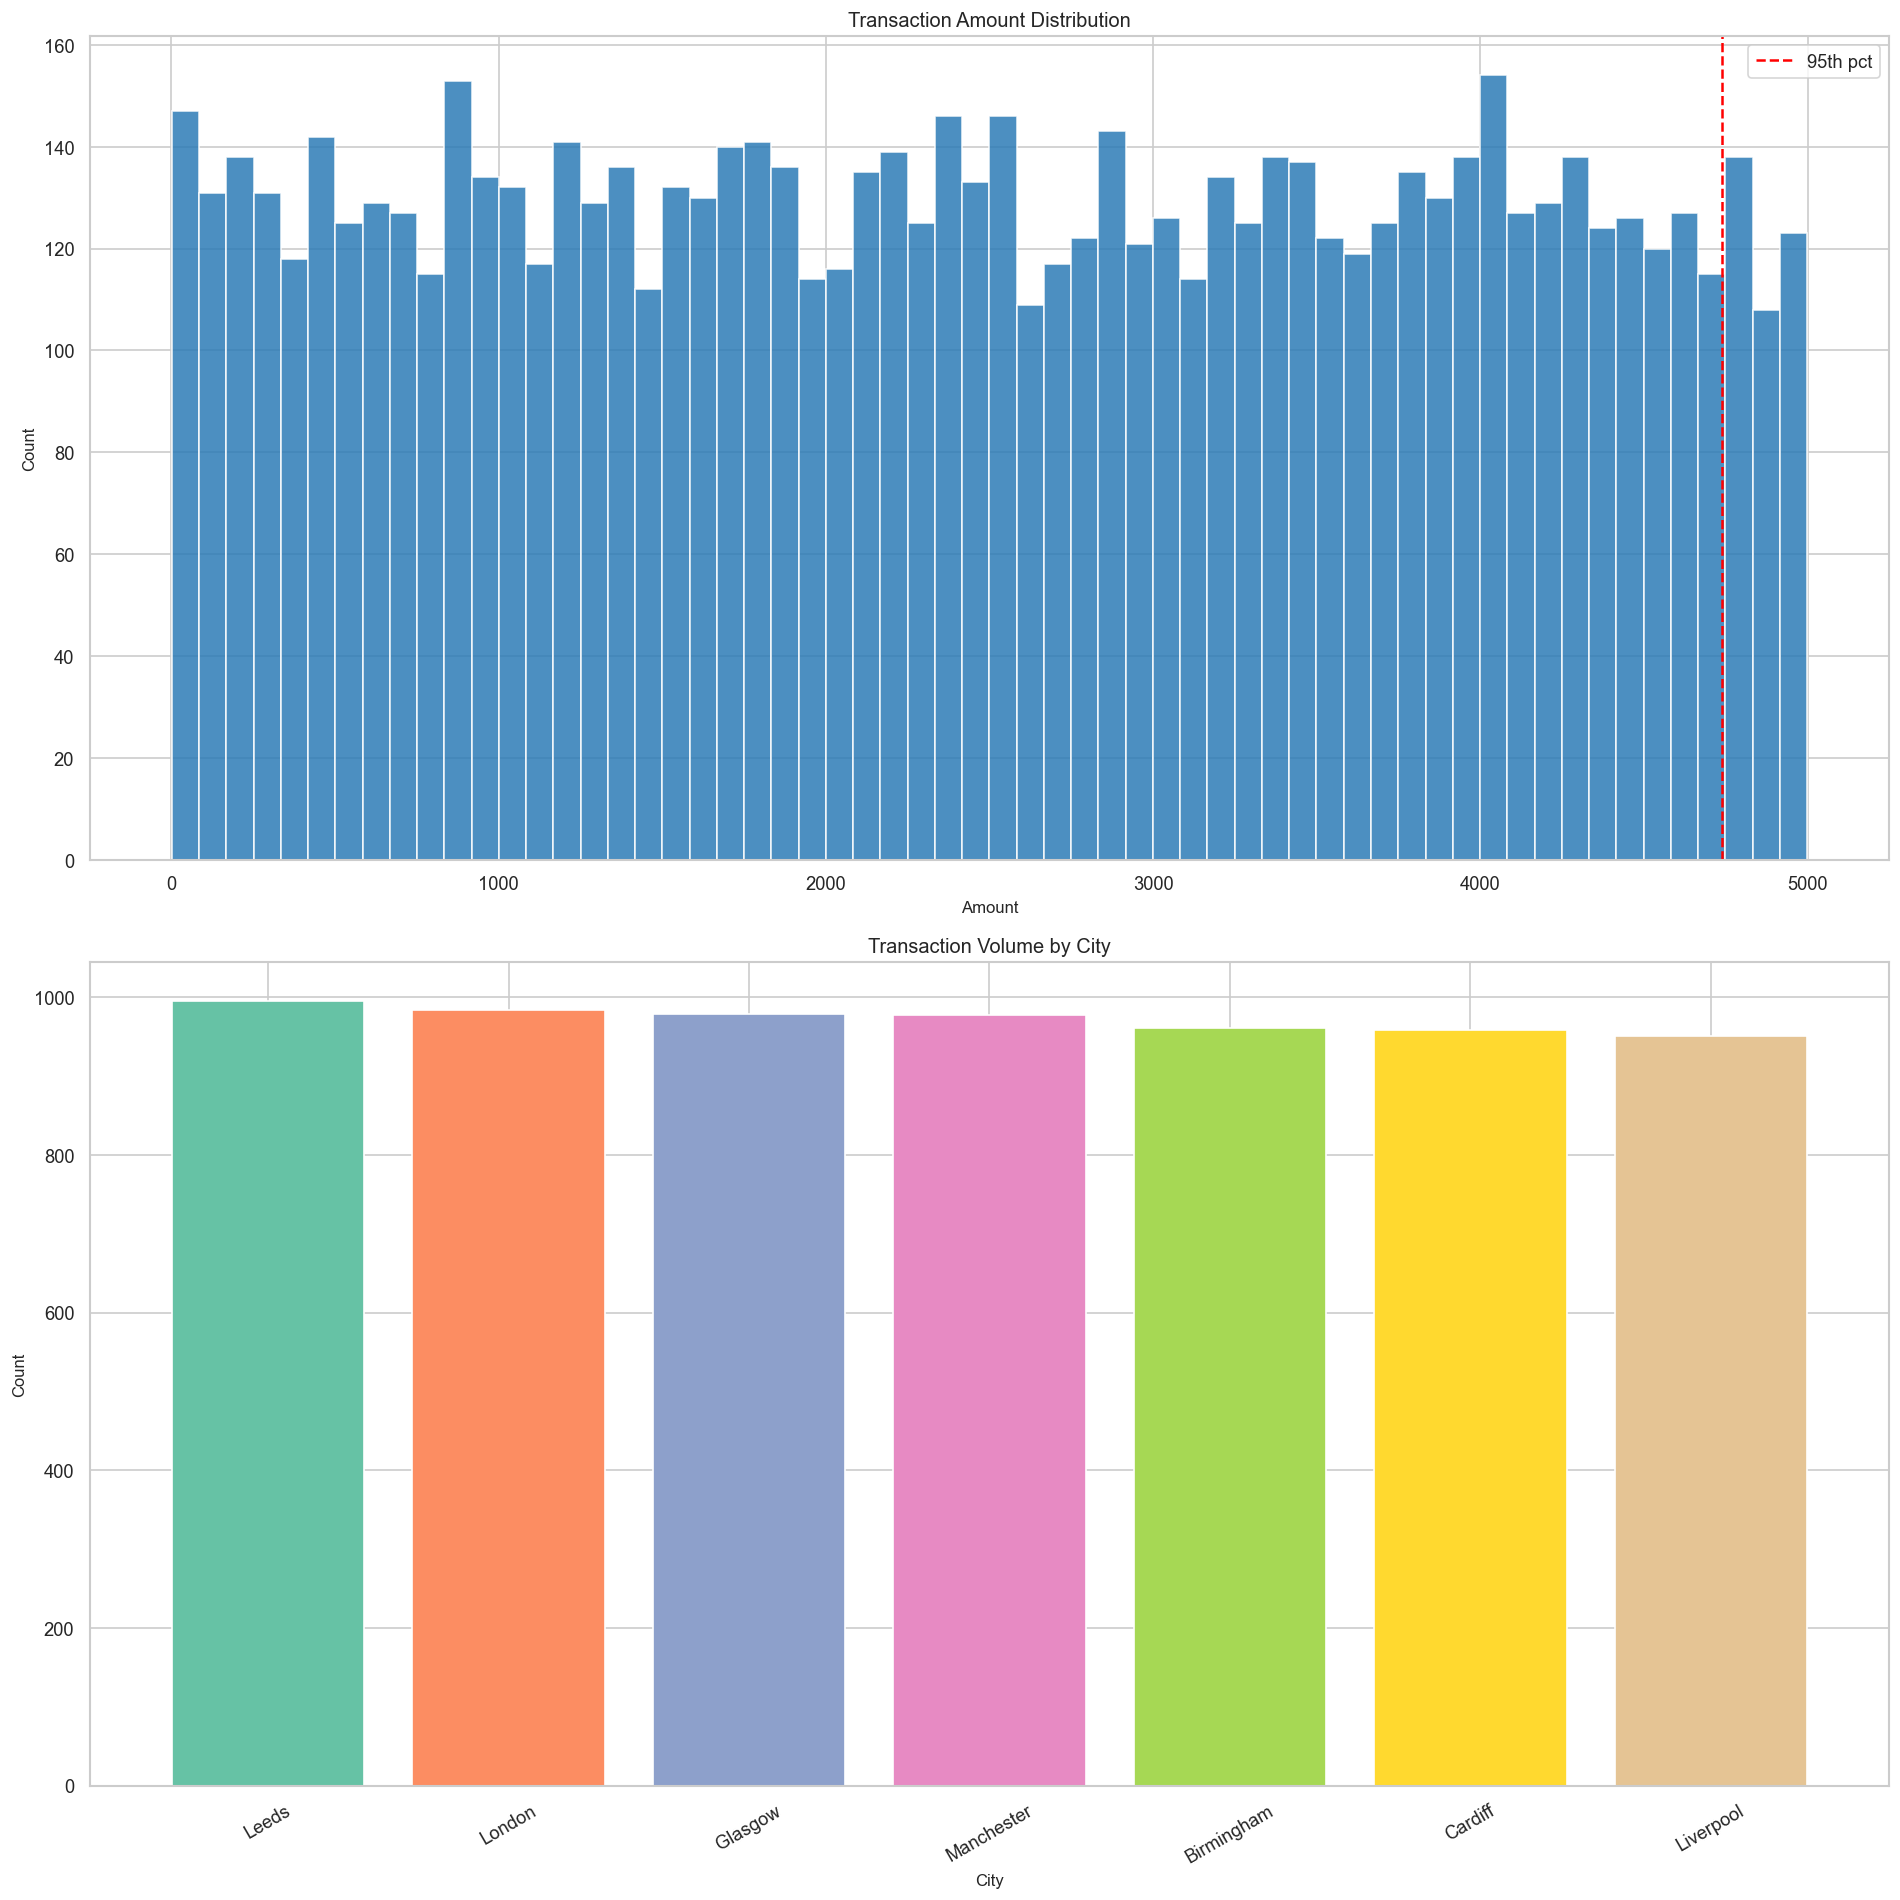

In [38]:
# ── EDA Plot 1: Transaction Amount Distribution ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

# Overall distribution
axes[0].hist(clean_df["amount"].dropna(), bins=60, color="#2c7bb6", edgecolor="white", alpha=0.85)
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count")
axes[0].axvline(clean_df["amount"].quantile(0.95), color="red",
                linestyle="--", label="95th pct")
axes[0].legend()


# City distribution
city_counts = clean_df[clean_df["city"] != "UNKNOWN"]["city"].value_counts()
axes[1].bar(city_counts.index, city_counts.values,
            color=sns.color_palette("Set2", len(city_counts)))
axes[1].set_title("Transaction Volume by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


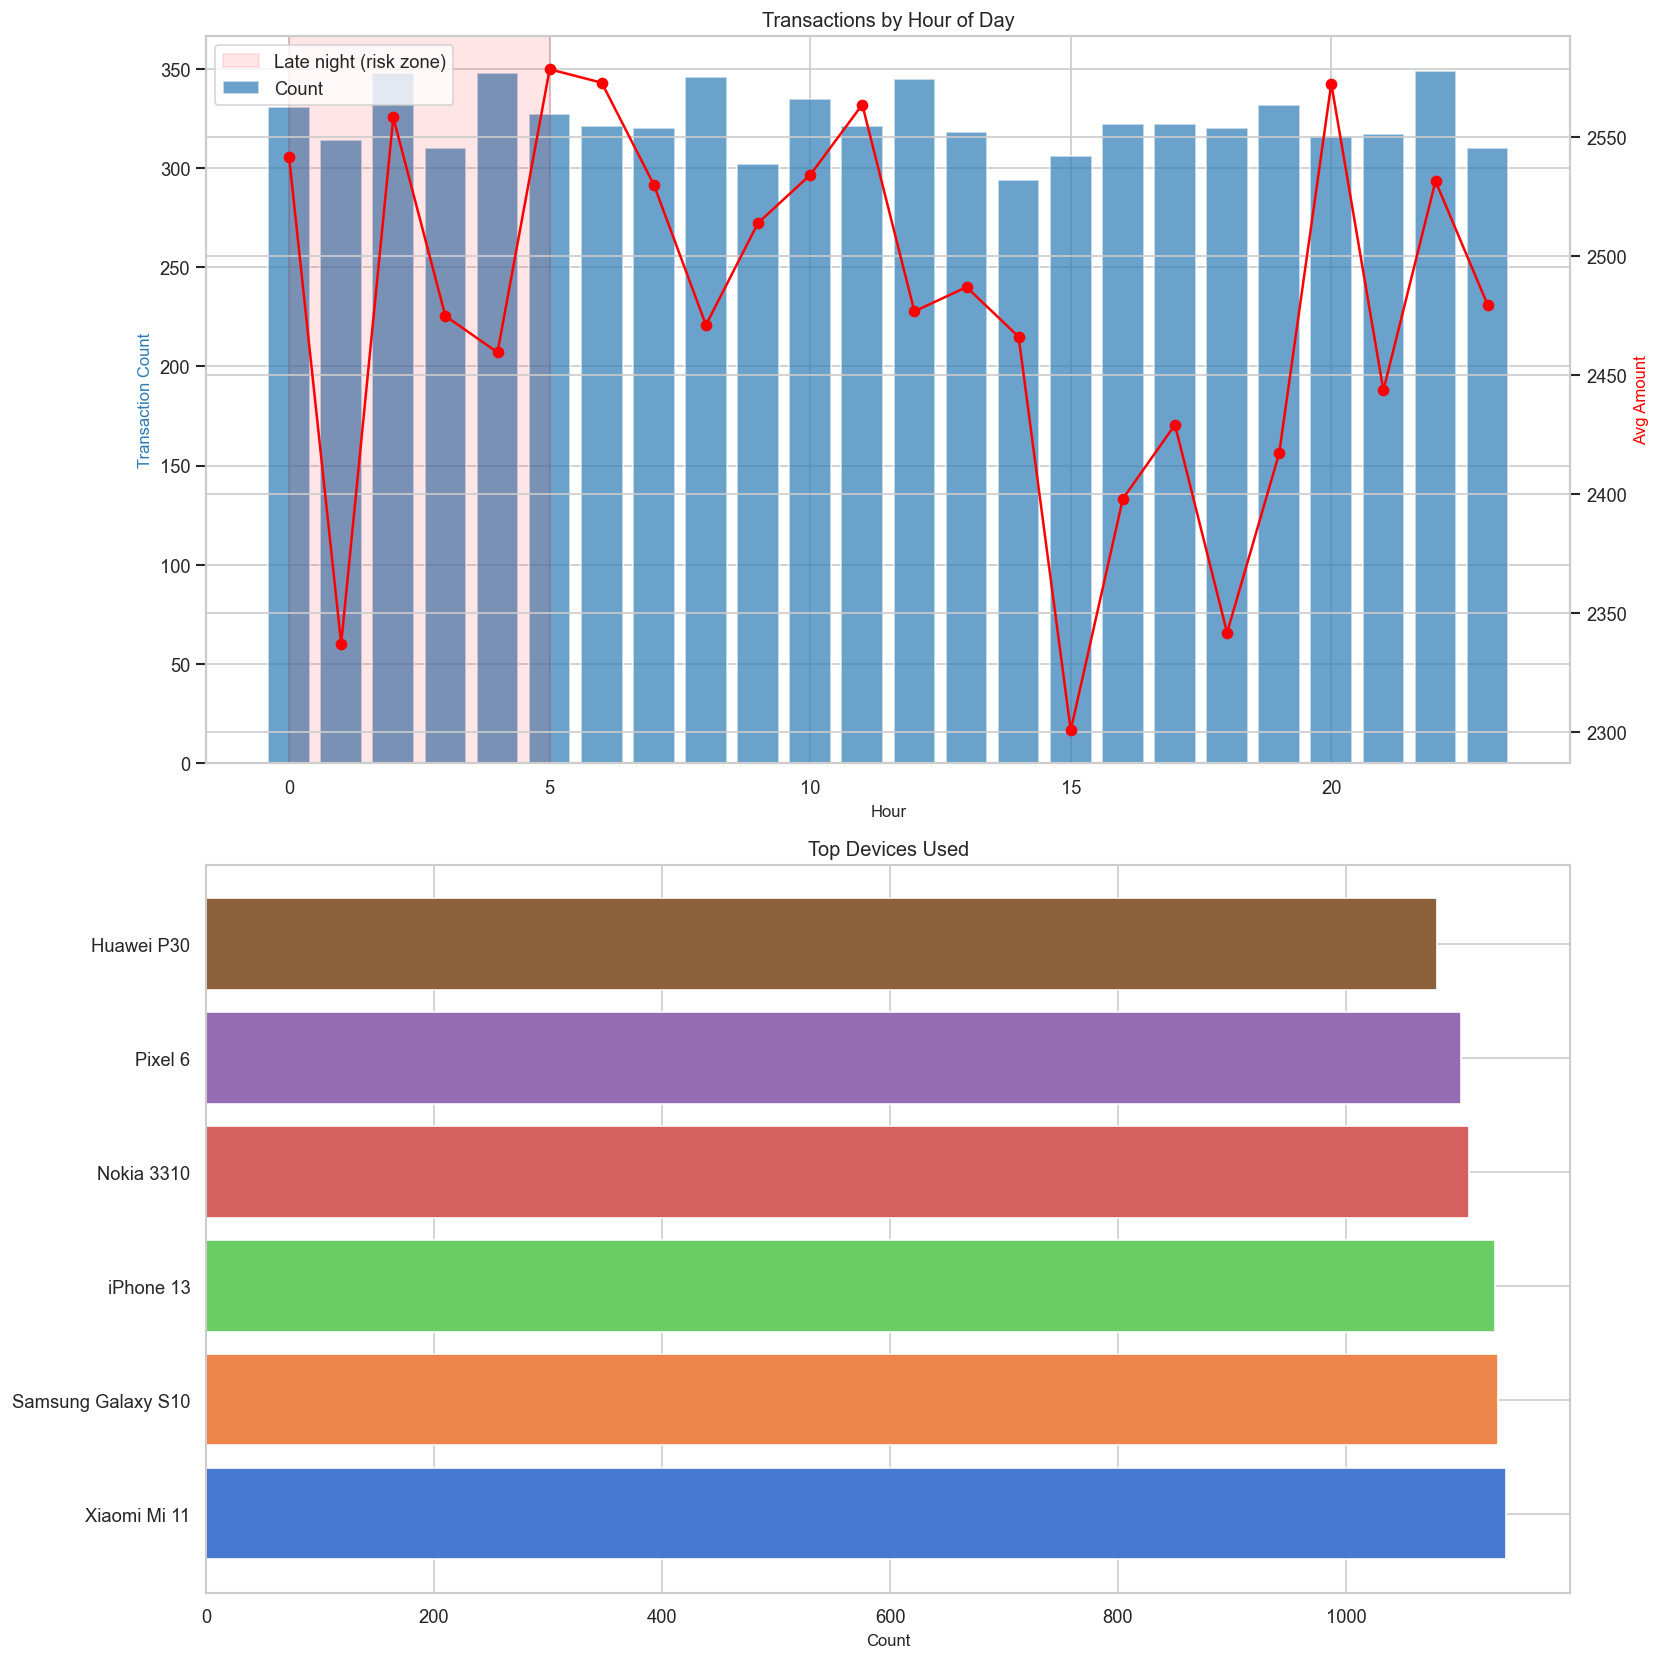

In [40]:
# ── EDA Plot 2: Temporal Patterns ─────────────────────────────────────────
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["dow"]  = clean_df["timestamp"].dt.day_name()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Hourly heatmap
hourly = clean_df.groupby("hour")["amount"].agg(["count","mean"]).reset_index()
ax2 = axes[0].twinx()
axes[0].bar(hourly["hour"], hourly["count"], color="#2c7bb6", alpha=0.7, label="Count")
ax2.plot(hourly["hour"], hourly["mean"], color="red", marker="o", label="Avg Amount")
axes[0].set_title("Transactions by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transaction Count", color="#2c7bb6")
ax2.set_ylabel("Avg Amount", color="red")
axes[0].axvspan(0, 5, alpha=0.1, color="red", label="Late night (risk zone)")
axes[0].legend(loc="upper left")

# Device distribution
device_counts = clean_df[clean_df["device"] != "UNKNOWN"]["device"].value_counts().head(8)
axes[1].barh(device_counts.index, device_counts.values, color=sns.color_palette("muted", 8))
axes[1].set_title("Top Devices Used")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


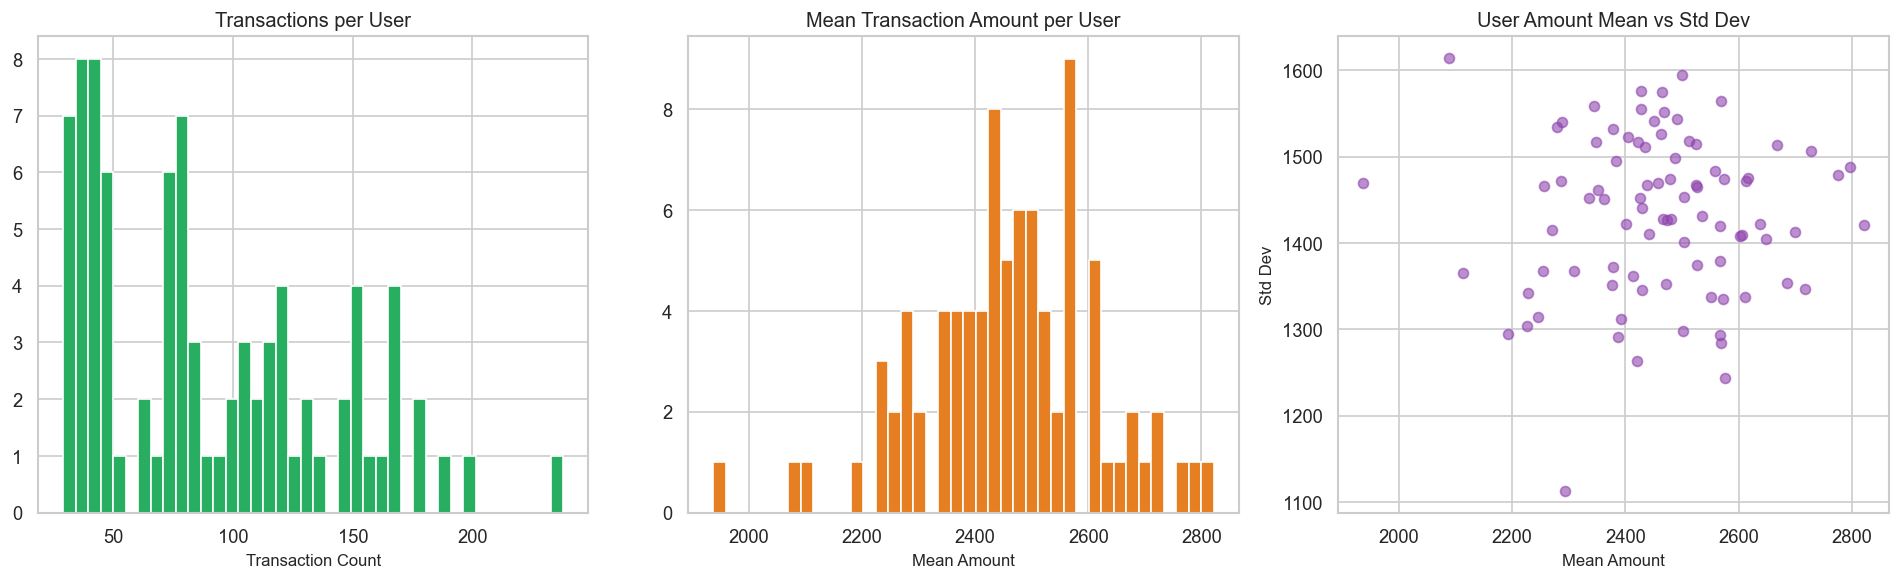

User behavioral stats: 
        count     mean      std      max     cv
count   86.00    86.00    86.00    86.00  86.00
mean    90.40  2459.73  1432.68  4911.61   0.58
std     49.99   157.32    92.64   107.08   0.05
min     29.00  1937.03  1112.70  4449.64   0.48
25%     44.00  2378.07  1365.45  4875.70   0.54
50%     80.00  2465.82  1445.88  4957.04   0.58
75%    120.75  2567.38  1504.88  4982.16   0.62
max    238.00  2821.43  1614.52  4998.25   0.77


In [47]:
# ── EDA Plot 3: Per-User Behavioral Profiles ──────────────────────────────
user_stats = clean_df.groupby("user_id")["amount"].agg(
    count="count", mean="mean", std="std", max="max"
).reset_index()
user_stats["cv"] = user_stats["std"] / user_stats["mean"]  # coefficient of variation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(user_stats["count"], bins=40, color="#27ae60", edgecolor="white")
axes[0].set_title("Transactions per User")
axes[0].set_xlabel("Transaction Count")

axes[1].hist(user_stats["mean"], bins=40, color="#e67e22", edgecolor="white")
axes[1].set_title("Mean Transaction Amount per User")
axes[1].set_xlabel("Mean Amount")

axes[2].scatter(user_stats["mean"], user_stats["std"], alpha=0.6, color="#8e44ad")
axes[2].set_title("User Amount Mean vs Std Dev")
axes[2].set_xlabel("Mean Amount")
axes[2].set_ylabel("Std Dev")

plt.tight_layout()
plt.show()
print(f"User behavioral stats: \n{user_stats.describe().round(2)}")


## 4. Feature Engineering

**All features are point-in-time correct:**
- Sorted by `(user_id, timestamp)` before any aggregate
- `.shift(1)` applied before every `.expanding()` window
- This ensures no transaction's history includes itself or future transactions
- Cold-start users (< 3 prior transactions) receive global population priors

**Fit window / Score window split:**
- Fit window = first 70% of data by timestamp
- All rarity encodings, vocabs, and scalers are fit on this window only
- Model scoring covers ALL transactions (fit + score window)
- This mirrors production: model trained on historical data, scored on new data


In [ ]:
# ── Temporal fit/score split ────────────────────────────────────────────────
# Sort full dataset by timestamp for splitting
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"])
clean_df = clean_df.sort_values("timestamp").reset_index(drop=True)

cutoff_idx = int(len(clean_df) * 0.70)
fit_df     = clean_df.iloc[:cutoff_idx].copy()
score_df   = clean_df.copy()   # score ALL transactions

print(f"Fit window   : {len(fit_df)} rows "
      f"({fit_df['timestamp'].min().date()} → {fit_df['timestamp'].max().date()})")
print(f"Score window : {len(score_df)} rows "
      f"({score_df['timestamp'].min().date()} → {score_df['timestamp'].max().date()})")
print(f"\\nNote: Rarity encodings, scalers, and model parameters are "
      f"established on the fit window only.")


In [ ]:
# ── Compute global priors (cold-start fallback) ─────────────────────────────
global_priors = compute_global_priors(fit_df)
print("Global priors (used for cold-start users):")
for k, v in global_priors.items():
    print(f"  {k:<30} : {v:.4f}")


In [ ]:
# ── Compute rarity encodings from fit window ────────────────────────────────
rarity_encodings = compute_rarity_encodings(fit_df)
print(f"\\nRarity encodings computed from fit window ({rarity_encodings['n_fit']} rows)")
print(f"  Unique cities  : {len(rarity_encodings['city_rarity'])}")
print(f"  Unique devices : {len(rarity_encodings['device_rarity'])}")
print(f"  Unique device-city pairs: {len(rarity_encodings['device_city_pair_rarity'])}")


In [ ]:
# ── Engineer all features (on full dataset — point-in-time correct) ──────────
# This is the core feature engineering step.
# Even though we compute features on all data, each feature value at row t
# only uses information from rows < t for the same user.
print("Engineering features on full dataset...")
featured_df = engineer_features(score_df, global_priors, rarity_encodings)

print(f"\\nFeature engineering complete.")
print(f"  Rows           : {len(featured_df)}")
print(f"  Total columns  : {len(featured_df.columns)}")
print(f"  Feature columns: {len(CONTINUOUS_FEATURES)}")
print(f"  Cold-start rows: {featured_df['is_cold_start'].sum()}")
print(f"\\nSample of engineered features:")
feat_cols = ["user_id","amount","amount_zscore","is_new_city",
             "user_txn_velocity_1h","is_cold_start","city_global_rarity"]
featured_df[feat_cols].head(8)


In [ ]:
# ── Feature distribution overview ───────────────────────────────────────────
key_features = ["amount_zscore", "user_txn_velocity_1h", "city_global_rarity",
                "device_global_rarity", "device_city_pair_rarity",
                "time_since_last_txn_sec", "user_location_entropy"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in featured_df.columns:
        data = featured_df[feat].dropna()
        axes[i].hist(data.clip(data.quantile(0.01), data.quantile(0.99)),
                     bins=40, color="#3498db", edgecolor="white", alpha=0.8)
        axes[i].set_title(feat, fontsize=9)
        axes[i].set_xlabel("Value", fontsize=8)

# Hide unused axes
for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/feature_distributions.png", bbox_inches="tight", dpi=150)
plt.show()


## 5. Layer 1 — Rule Engine

Rules are **user-context-aware**: they use each user's own historical behaviour
rather than fixed global thresholds. For example, `LATE_NIGHT_UNUSUAL` only fires
if the user rarely transacts at night — not for every nighttime transaction.


In [ ]:
# Apply rule engine to all transactions
ruled_df = apply_rules(featured_df)

print(f"\\nRule flag distribution:")
print(ruled_df["rule_flag_count"].value_counts().sort_index().to_string())
print(f"\\nTop rules triggered:")
from collections import Counter
all_flags = []
for flags in ruled_df["rule_flags"]:
    if flags and flags != "NONE":
        all_flags.extend(flags.split(" | "))
flag_counts = Counter(all_flags)
for flag, cnt in flag_counts.most_common():
    print(f"  {flag:<35} {cnt}")


In [ ]:
# ── Rule flag visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flag count distribution
flag_dist = ruled_df["rule_flag_count"].value_counts().sort_index()
colors = ["#27ae60" if i==0 else "#f39c12" if i<=2 else "#e74c3c"
          for i in flag_dist.index]
axes[0].bar(flag_dist.index, flag_dist.values, color=colors)
axes[0].set_title("Number of Rules Triggered per Transaction")
axes[0].set_xlabel("Rule Flag Count")
axes[0].set_ylabel("Number of Transactions")

# Top rules triggered
if flag_counts:
    top_flags = dict(flag_counts.most_common(9))
    axes[1].barh(list(top_flags.keys()), list(top_flags.values()),
                 color="#e74c3c", alpha=0.8)
    axes[1].set_title("Most Frequently Triggered Rules")
    axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("outputs/rule_analysis.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Layer 2 — Isolation Forest

**Why Isolation Forest for this use case:**
- Handles high-dimensional feature spaces natively (no PCA needed)
- Robust to small contamination of anomalies in training data
- Fast: O(n log n) complexity
- Provides continuous anomaly scores for ranking

**What it captures:** Global outliers — transactions that are rare in the
overall population distribution of continuous + rarity-encoded features.

**Independence from Autoencoder:** Categoricals are encoded as rarity scores
(city_global_rarity, device_global_rarity, pair_rarity), derived directly
from raw data — NOT from the autoencoder. This preserves model independence.


In [ ]:
# Fit Isolation Forest on fit window, score all transactions
if_detector = IsolationForestDetector(
    contamination=0.05,     # assume ~5% anomaly rate
    n_estimators=200,
    random_state=42,
)

# Fit on fit window only
if_detector.fit(ruled_df[ruled_df["timestamp"] <= ruled_df["timestamp"].quantile(0.70)])

# Score all transactions
if_scored_df = if_detector.score(ruled_df)

print(f"\\nIsolation Forest score statistics:")
print(if_scored_df["if_score"].describe().round(4))


In [ ]:
# ── SHAP values for top anomalies ───────────────────────────────────────────
# Compute SHAP on top-100 anomalies (can extend to full df if performance allows)
top100 = if_scored_df.nlargest(100, "if_score")
shap_values = if_detector.get_shap_values(top100)
feature_names = if_detector.get_feature_names()

if shap_values is not None:
    # Mean absolute SHAP value per feature = global importance
    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_shap, index=feature_names[:len(mean_shap)])
    top_shap = shap_importance.sort_values(ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_shap.plot(kind="barh", ax=ax, color="#e74c3c", alpha=0.85)
    ax.set_title("Feature Importance for Anomaly Detection (Mean |SHAP|)", fontsize=12)
    ax.set_xlabel("Mean |SHAP Value|")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("outputs/shap_importance.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("SHAP not available — install with: pip install shap")
    shap_values = None


## 7. Layer 3 — Deep Autoencoder with Entity Embeddings

**Architecture:**
- **Two input streams:** continuous features + categorical entity embeddings
- **Embedding layers:** `user_id → 16-dim`, `city → 8-dim`, `device → 8-dim`, `txn_type → 4-dim`  
- **Encoder:** Dense(64) → BatchNorm → Dense(32) → BatchNorm → Dense(16) → Bottleneck(8)
- **Decoder:** Dense(16) → Dense(32) → Dense(64) → Output(continuous) + Softmax heads(categoricals)
- **Loss:** weighted MSE (continuous) + CrossEntropy (categorical reconstructions)

**Why entity embeddings here but not in IF:**
- IF uses rarity encodings (scalar, no cardinality issue)
- AE can learn rich user behavioral fingerprints via embeddings — `user_id` embedding
  captures transaction pattern, typical city/device/amount. Anomaly = user behaves
  unlike their learned fingerprint → high reconstruction error.

**Independence:** AE is trained directly on raw data features, not on IF outputs.


In [ ]:
# ── Fit Autoencoder ─────────────────────────────────────────────────────────
# The autoencoder is trained independently of Isolation Forest.
# It receives both continuous features AND entity embeddings for categoricals.

ae_detector = AutoencoderDetector(
    epochs=50,
    batch_size=64,
    lr=1e-3,
    cont_loss_weight=0.6,   # 60% weight on continuous reconstruction
    cat_loss_weight=0.1,    # 10% per categorical (4 × 10% = 40%)
)

# Fit on fit window only
fit_mask = if_scored_df["timestamp"] <= if_scored_df["timestamp"].quantile(0.70)
ae_detector.fit(if_scored_df[fit_mask])


In [ ]:
# ── Score all transactions ───────────────────────────────────────────────────
ae_scored_df = ae_detector.score(if_scored_df)

print(f"\\nAutoencoder reconstruction error statistics:")
print(ae_scored_df["ae_recon_error"].describe().round(6))


In [ ]:
# ── Per-feature reconstruction error (for explainability) ─────────────────
per_feature_recon_df = ae_detector.get_per_feature_recon_error(ae_scored_df)
if not per_feature_recon_df.empty:
    print("Mean reconstruction error by feature (top 10):")
    print(per_feature_recon_df.mean().sort_values(ascending=False).head(10).round(4))


In [ ]:
# ── User Embedding Visualization ────────────────────────────────────────────
user_embeddings = ae_detector.get_user_embeddings(ae_scored_df)

if user_embeddings is not None:
    from sklearn.decomposition import PCA

    emb_cols = [c for c in user_embeddings.columns if c.startswith("user_emb_")]
    pca = PCA(n_components=2, random_state=42)
    emb_2d = pca.fit_transform(user_embeddings[emb_cols].values)

    # Merge with per-user risk scores
    user_risk = (ae_scored_df.groupby("user_id")["ae_score"]
                              .mean()
                              .reset_index()
                              .rename(columns={"ae_score": "avg_risk"}))
    plot_df = user_embeddings[["user_id"]].copy()
    plot_df["pca_1"] = emb_2d[:, 0]
    plot_df["pca_2"] = emb_2d[:, 1]
    plot_df = plot_df.merge(user_risk, on="user_id", how="left")

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(plot_df["pca_1"], plot_df["pca_2"],
                    c=plot_df["avg_risk"], cmap="RdYlGn_r",
                    s=80, alpha=0.8, edgecolors="white", linewidths=0.5)
    plt.colorbar(sc, ax=ax, label="Avg User Risk Score")
    ax.set_title("User Behavioral Fingerprints (Learned Embeddings, PCA 2D)", fontsize=12)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    plt.tight_layout()
    plt.savefig("outputs/user_embeddings_pca.png", bbox_inches="tight", dpi=150)
    plt.show()


## 8. Ensemble Scoring

**Equal weights are the principled default** when no analyst feedback is available.
Weights should be tuned via precision-at-K once analyst-reviewed labels accumulate.

Final risk score = 0.33 × rule_score + 0.33 × if_score + 0.34 × ae_score

Risk tiers:
- **TIER 1** (≥ 0.75): Auto-block / immediate review
- **TIER 2** (0.50–0.75): Step-up authentication  
- **TIER 3** (0.25–0.50): Silent monitoring
- **NORMAL** (< 0.25): No action


In [ ]:
# ── Compute ensemble risk scores ────────────────────────────────────────────
final_df = compute_ensemble_score(ae_scored_df)

print(f"\\nFinal risk score statistics:")
print(final_df["final_risk_score"].describe().round(4))


In [ ]:
# ── Risk tier visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Risk score distribution
axes[0].hist(final_df["final_risk_score"], bins=60,
             color="#2c7bb6", edgecolor="white", alpha=0.85)
axes[0].axvline(0.75, color="red",    linestyle="--", linewidth=2, label="Tier 1")
axes[0].axvline(0.50, color="orange", linestyle="--", linewidth=2, label="Tier 2")
axes[0].axvline(0.25, color="green",  linestyle="--", linewidth=2, label="Tier 3")
axes[0].set_title("Ensemble Risk Score Distribution")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Risk tier pie
tier_counts = final_df["risk_tier"].value_counts()
tier_colors = {"TIER_1": "#e74c3c", "TIER_2": "#e67e22", "TIER_3": "#f1c40f", "NORMAL": "#27ae60"}
colors = [tier_colors.get(t, "#95a5a6") for t in tier_counts.index]
axes[1].pie(tier_counts.values, labels=tier_counts.index,
            colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Risk Tier Distribution")

# Model agreement distribution
if "model_agreement" in final_df.columns:
    agree_counts = final_df["model_agreement"].value_counts().sort_index()
    axes[2].bar(agree_counts.index, agree_counts.values,
                color=["#27ae60","#f39c12","#e67e22","#e74c3c"][:len(agree_counts)])
    axes[2].set_title("Model Agreement\n(how many models flagged each transaction)")
    axes[2].set_xlabel("Number of Models in Agreement")
    axes[2].set_ylabel("Count")
    axes[2].set_xticks(agree_counts.index)

plt.tight_layout()
plt.savefig("outputs/ensemble_results.png", bbox_inches="tight", dpi=150)
plt.show()


In [ ]:
# ── Score correlation between models ─────────────────────────────────────────
score_cols = ["rule_score", "if_score", "ae_score", "final_risk_score"]
corr_matrix = final_df[score_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdYlGn_r",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Model Score Correlations\\n(lower = more independent = better ensemble)")
plt.tight_layout()
plt.savefig("outputs/score_correlations.png", bbox_inches="tight", dpi=150)
plt.show()

print("Ideal: pairwise correlation < 0.5 (models detecting different patterns)")
print(f"IF ↔ AE correlation   : {corr_matrix.loc['if_score','ae_score']:.3f}")
print(f"IF ↔ Rule correlation : {corr_matrix.loc['if_score','rule_score']:.3f}")
print(f"AE ↔ Rule correlation : {corr_matrix.loc['ae_score','rule_score']:.3f}")


## 9. Evaluation

**Evaluation strategy for unlabeled data:**

1. **Synthetic injection test** — Known fraud patterns injected at data generation.
   We measure what fraction appear in the top-K scored transactions.
2. **Precision-at-K** — Of the top-K transactions by risk score, what fraction are genuine anomalies?
3. **Cross-model agreement** — What fraction of each model's top-5% overlap with others?
   (Low overlap = independent, non-redundant detectors — good for ensembles)
4. **Score distribution** — Bimodal distribution = model found structure.
5. **Anomaly rate check** — Flagged rate should align with industry baseline (0.5–3%).


In [ ]:
# ── Run full evaluation suite ────────────────────────────────────────────────
os.makedirs("outputs", exist_ok=True)
eval_results = run_full_evaluation(final_df)


In [ ]:
# ── Score distribution plots ─────────────────────────────────────────────────
fig = plot_score_distributions(final_df, save_path="outputs/score_distributions.png")
plt.show()


In [ ]:
# ── Cross-model agreement heatmap ────────────────────────────────────────────
agreement_matrix = cross_model_agreement(final_df, top_pct=0.05)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt=".2%",
            cmap="Blues", ax=ax, vmin=0, vmax=1,
            linewidths=1, linecolor="white")
ax.set_title("Cross-Model Flag Overlap\\n(top 5% by each model's score)")
plt.tight_layout()
plt.savefig("outputs/model_agreement.png", bbox_inches="tight", dpi=150)
plt.show()
print("\\nTarget: off-diagonal values < 0.50 (independent detectors)")


In [ ]:
# ── 2D PCA visualization of transactions colored by risk score ───────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feat_cols_for_viz = [c for c in CONTINUOUS_FEATURES if c in final_df.columns]
X_viz = final_df[feat_cols_for_viz].fillna(0).values

scaler_viz = StandardScaler()
X_scaled   = scaler_viz.fit_transform(X_viz)

pca_viz    = PCA(n_components=2, random_state=42)
X_2d       = pca_viz.fit_transform(X_scaled)

final_df["pca_1"] = X_2d[:, 0]
final_df["pca_2"] = X_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colored by ensemble risk score
sc1 = axes[0].scatter(
    final_df["pca_1"], final_df["pca_2"],
    c=final_df["final_risk_score"],
    cmap="RdYlGn_r", s=20, alpha=0.7, edgecolors="none"
)
plt.colorbar(sc1, ax=axes[0], label="Risk Score")
axes[0].set_title("Transaction Space (PCA 2D)\\nColored by Ensemble Risk Score")
axes[0].set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var)")

# Colored by risk tier
tier_color_map = {"TIER_1": "#e74c3c", "TIER_2": "#e67e22",
                  "TIER_3": "#f1c40f", "NORMAL": "#2ecc71"}
tier_colors_plot = final_df["risk_tier"].map(tier_color_map).fillna("#95a5a6")
axes[1].scatter(final_df["pca_1"], final_df["pca_2"],
                c=tier_colors_plot, s=20, alpha=0.7, edgecolors="none")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in tier_color_map.items()]
axes[1].legend(handles=legend_elements, loc="upper right")
axes[1].set_title("Transaction Space (PCA 2D)\\nColored by Risk Tier")
axes[1].set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var)")

plt.tight_layout()
plt.savefig("outputs/anomaly_clusters.png", bbox_inches="tight", dpi=150)
plt.show()


In [ ]:
# ── Risk score vs amount — anomaly scatter ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

tier_color_map = {"TIER_1":"#e74c3c","TIER_2":"#e67e22","TIER_3":"#f1c40f","NORMAL":"#2ecc71"}
for tier, grp in final_df.groupby("risk_tier"):
    ax.scatter(
        grp["timestamp"], grp["amount"],
        c=tier_color_map.get(tier, "#95a5a6"),
        s=grp["final_risk_score"] * 60 + 5,
        alpha=0.6, label=tier, edgecolors="none"
    )

ax.set_title("Transaction Timeline: Amount vs Time (size = risk score, color = tier)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Transaction Amount")
legend_elements = [Patch(facecolor=v, label=k) for k,v in tier_color_map.items()]
ax.legend(handles=legend_elements)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/risk_timeline.png", bbox_inches="tight", dpi=150)
plt.show()


## 11. Explainability — Per-Transaction Fraud Reports

For each high-risk transaction, we produce a structured investigation report combining:
- Rule flags with plain-English explanations
- SHAP feature importances (from Isolation Forest)
- Autoencoder per-feature reconstruction error
- Recommended business action


In [ ]:
# ── Compute SHAP on all transactions (may take a moment) ─────────────────────
print("Computing SHAP values for all transactions...")
shap_matrix = if_detector.get_shap_values(final_df)
feature_names_list = if_detector.get_feature_names()
print(f"SHAP matrix shape: {shap_matrix.shape if shap_matrix is not None else 'N/A'}")


In [ ]:
# ── Generate fraud reports for top-10 highest risk transactions ─────────────
reports = generate_batch_reports(
    df=final_df,
    top_n=10,
    feature_names=feature_names_list,
    shap_matrix=shap_matrix,
    per_feature_recon_df=per_feature_recon_df if not per_feature_recon_df.empty else None,
)

for report in reports[:3]:   # Print first 3 in notebook
    print(report)


In [ ]:
# Save all reports to file
os.makedirs("outputs", exist_ok=True)
with open("outputs/top_anomaly_reports.txt", "w") as f:
    for report in reports:
        f.write(report + "\\n")
print(f"Saved {len(reports)} fraud reports → outputs/top_anomaly_reports.txt")


In [ ]:
# ── Summary table of top-20 anomalies ───────────────────────────────────────
display_cols = [
    "user_id", "timestamp", "amount", "currency", "city", "device", "txn_type",
    "final_risk_score", "risk_tier", "model_agreement",
    "rule_flags", "if_score", "ae_score",
]
display_cols = [c for c in display_cols if c in final_df.columns]

top_20 = get_top_anomalies(final_df, top_n=20)[display_cols]

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_columns", 20)
print("Top 20 Highest-Risk Transactions:")
top_20


In [ ]:
# Export results
final_df.to_csv("outputs/scored_transactions.csv", index=False)
top_20.to_csv("outputs/top_anomalies.csv", index=False)
print("\\n✅ Results exported:")
print("   outputs/scored_transactions.csv — all transactions with risk scores")
print("   outputs/top_anomalies.csv       — top 20 highest-risk transactions")
print("   outputs/top_anomaly_reports.txt — detailed fraud investigation reports")


## 13. Business Impact & Recommendations

### Risk-Response Framework

| Tier | Threshold | Action | Rationale |
|---|---|---|---|
| TIER 1 | ≥ 0.75 | Auto-block + immediate notification | High confidence fraud, cost of false positive < cost of fraud |
| TIER 2 | 0.50–0.75 | Step-up authentication (OTP/biometric) | Suspicious but uncertain — verify without disrupting genuine users |
| TIER 3 | 0.25–0.50 | Silent monitoring + enhanced velocity tracking | Low-confidence signal — monitor without friction |
| NORMAL | < 0.25 | No action | Transaction appears within normal behavioral range |

### Weight Tuning Pathway
Current equal weights (0.33/0.33/0.34) are the principled default with no analyst labels.
As fraud analysts review flagged transactions, their decisions accumulate as pseudo-labels.
Weights are then tuned to maximize **precision-at-K** on that labeled set.

### Cold-Start Users
New users with < 3 transactions receive global population priors. In production, this is
supplemented by:
1. **Segment-based priors** — new user inherits the risk profile of their segment
2. **Graph-based identity linkage** — device fingerprint / email domain matching to existing accounts
3. **Conservative thresholds** — lower fraud score threshold for first 10 transactions

### Model Refresh Cadence
- Retrain on rolling 90-day window (weekly batch job)
- Monitor anomaly rate drift: if flagged rate exceeds 2× baseline → alert for model drift
- Entity vocabularies (user_id, city, device) updated with each batch retraining cycle

### Expected Impact
At 1000 transactions/day with 1% genuine fraud rate and 80% precision-at-Tier1:
- ~10 genuine fraud cases/day
- Tier 1 catches ~6 cases automatically (assuming 60% recall)
- At avg fraud value of £1,500 → **£9,000/day protected**
- Annual exposure reduction: **~£3.3M** before false positive cost
